In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../pysimARG')
from clonal_genealogy import ClonalTree
from ClonalOrigin_nodes import ClonalOrigin_nodes
from ClonalOrigin_ARG import ARG
from add_mutation import add_mutation
from add_mutation_truncated import add_mutation_truncated
from G3_test import G3_test
from LD_r import LD_r
from homoplasy_index import homoplasy_index
from ClonalOrigin_seq_sim import ClonalOrigin_seq_simulator

## Check inputs

In [2]:
tree1 = ClonalTree(n=10)

In [3]:
print(tree1)

ClonalTree(n=10)


In [4]:
tree1.edge

array([[11.        ,  4.        ,  0.02949854],
       [11.        ,  5.        ,  0.02949854],
       [12.        ,  9.        ,  0.04056632],
       [12.        ,  3.        ,  0.04056632],
       [13.        ,  8.        ,  0.07395614],
       [13.        ,  6.        ,  0.07395614],
       [14.        , 12.        ,  0.0404031 ],
       [14.        ,  7.        ,  0.08096942],
       [15.        , 11.        ,  0.08090285],
       [15.        , 14.        ,  0.02943196],
       [16.        ,  2.        ,  0.34225366],
       [16.        , 10.        ,  0.34225366],
       [17.        , 16.        ,  0.17745924],
       [17.        ,  1.        ,  0.5197129 ],
       [18.        , 17.        ,  0.58210237],
       [18.        , 13.        ,  1.02785912],
       [19.        , 15.        ,  1.8603363 ],
       [19.        , 18.        ,  0.86892242]])

In [5]:
tree1.node_height

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.02949854, 0.04056632, 0.07395614, 0.08096942, 0.11040138,
       0.34225366, 0.5197129 , 1.10181526, 1.97073768])

## Fix inputs

In [ ]:
n = 5
clonal_edge = np.array([
     [6,     5, 0.2692641],
     [6,     1, 0.2692641],
     [7,     3, 0.3830430],
     [7,     2, 0.3830430],
     [8,     7, 0.2135823],
     [8,     6, 0.3273612],
     [9,     4, 0.7508066],
     [9,     8, 0.1541813]
])
clonal_node_height = np.array([0.0000000, 0.0000000, 0.0000000, 0.0000000, 0.0000000, 0.2692641, 0.3830430, 0.5966253, 0.7508066])

In [ ]:
rho_site = 0.5
L = 100
rho = L * rho_site
delta = 5.0
k = 20

## Check part 1

In [ ]:
# Tree length
tree_length = np.sum(clonal_edge[:, 2])

# Initialize recombination edges
nrow_max = 1000
# Columns: b_edge, b_height, a_edge, a_height, x, y
recomb_edge = np.full((nrow_max, 6), np.nan)

# Add recombination sequentially
n_recomb = 0
remain_index = np.array([], dtype=int)

In [ ]:
for i in range(1, k+1):  # i = 1, 2, ..., k
        if i == 1:
            R_new = np.random.poisson(rho_site * delta * tree_length / 2)
            R_old = 0
        else: # i == 2, ..., k
            survive_index = np.where(recomb_edge[:n_recomb, 5] == (i - 1))[0] if n_recomb > 0 else np.array([], dtype=int)
            R_new = np.random.poisson(rho_site * tree_length / 2)

            R_old = np.random.binomial(1 * survive_index.size, (1 - 1 / delta))
            remain_index = np.random.choice(survive_index, size=R_old, replace=False)
        
        if R_new > 0:
            # Expand matrix if needed
            if n_recomb + R_new >= nrow_max:
                recomb_edge = np.vstack([recomb_edge, np.full((nrow_max + n_recomb + R_new, 6), np.nan)])
                nrow_max = 2 * nrow_max + n_recomb + R_new
            
            # Set x and y columns
            recomb_edge[n_recomb:n_recomb + R_new, 4] = i  # x
            recomb_edge[n_recomb:n_recomb + R_new, 5] = i  # y
            
            a_rexp = np.random.exponential(1.0, size=R_new)
            
            # Simulate b_edge (similar to mutation)
            # Sample edges with probability proportional to edge length
            edge_probs = clonal_edge[:, 2] / np.sum(clonal_edge[:, 2])
            recomb_edge[n_recomb:n_recomb + R_new, 0] = np.random.choice(
                range(1, (2*n-1)), R_new, replace=True, p=edge_probs
            )
            
            for j in range(R_new):
                idx = n_recomb + j
                b_edge_idx = int(recomb_edge[idx, 0]) - 1
                
                # Simulate b_height
                recomb_edge[idx, 1] = (
                    np.random.uniform(0, clonal_edge[b_edge_idx, 2]) +
                    clonal_node_height[int(clonal_edge[b_edge_idx, 1])-1]
                )
                
                # Identify a_height
                # t_above_b: heights of internal nodes minus b_height
                t_above_b = clonal_node_height[n:2*n-1] - recomb_edge[idx, 1]
                
                # Get positive values (nodes above b)
                positive_mask = t_above_b >= 0
                positive_t = t_above_b[positive_mask]
                
                # i_above_b with 0 prepended
                i_above_b_full = np.concatenate([[0], np.sort(positive_t)])
                i_above_b = np.diff(i_above_b_full)
                
                # Calculate cumulative values
                num_intervals = len(i_above_b)
                lineage_counts = np.arange(num_intervals + 1, 1, -1)
                cuml_above_b = np.cumsum(i_above_b * lineage_counts)
                
                # Determine number of lineages at coalescence time
                num_lineage = (num_intervals + 1) - np.sum(a_rexp[j] > cuml_above_b)
                
                if num_lineage == (num_intervals + 1):
                    recomb_edge[idx, 3] = a_rexp[j] / num_lineage + recomb_edge[idx, 1]
                else:
                    idx_cuml = num_intervals - num_lineage
                    recomb_edge[idx, 3] = (
                        (a_rexp[j] - cuml_above_b[idx_cuml]) / num_lineage +
                        np.sum(i_above_b[:idx_cuml + 1]) +
                        recomb_edge[idx, 1]
                    )
                
                # Simulate a_edge
                if num_lineage > 1:
                    a_height = recomb_edge[idx, 3]
                    # Find edges that span the a_height
                    pool_edge = np.where(
                        (clonal_node_height[clonal_edge[:, 0].astype(int)-1] >= a_height) &
                        (clonal_node_height[clonal_edge[:, 1].astype(int)-1] <  a_height)
                    )[0] + 1
                    recomb_edge[idx, 2] = np.random.choice(pool_edge)
                else:
                    # Root edge (using edge index 2*n-2 for 0-indexed)
                    recomb_edge[idx, 2] = 2 * n - 1
        
        if R_old > 0 and len(remain_index) > 0:
            recomb_edge[remain_index, 5] = i
        
        n_recomb = n_recomb + R_new

In [ ]:
n_recomb

In [ ]:
recomb_edge.shape

In [ ]:
# Trim recomb_edge to actual size
recomb_edge = recomb_edge[:n_recomb, :]
recomb_edge

In [ ]:
recomb_edge.shape

## Check part 2

In [ ]:
# Build full ARG
node_max = 2 * n - 1 + 3 * n_recomb
edge_max = 2 * (n - 1) + 4 * n_recomb

edge_matrix = np.full((edge_max, 3), np.nan)
edge_mat_index = np.full(edge_max, np.nan)
node_mat = np.full((node_max, k), np.nan)
node_info = np.full((node_max, 4), np.nan)
# Columns: index, height, recomb, clonal

node_mat[:n, :] = True
node_info[:, 0] = np.arange(1, node_max + 1)

# Set clonal node info
node_info[:2*n-1, 1] = clonal_node_height
node_info[:2*n-1, 2] = 0
node_info[:2*n-1, 3] = 1  # True -> 1

# Set recombination out nodes (b nodes)
# Interleave: for each recomb event, add two nodes at b_height
for r in range(n_recomb):
    base_idx = 2 * n - 1 + 2 * r
    node_info[base_idx, 1] = recomb_edge[r, 1]      # b_height
    node_info[base_idx, 2] = -(r + 1)               # negative recomb index (1-indexed)
    node_info[base_idx, 3] = 1                      # clonal = True
    
    node_info[base_idx + 1, 1] = recomb_edge[r, 1]  # same b_height
    node_info[base_idx + 1, 2] = np.nan             # NA
    node_info[base_idx + 1, 3] = 0                  # clonal = False

# Set recombination in nodes (a nodes)
for r in range(n_recomb):
    idx = 2 * n - 1 + 2 * n_recomb + r
    node_info[idx, 1] = recomb_edge[r, 3]           # a_height
    node_info[idx, 2] = r + 1                       # positive recomb index (1-indexed)
    node_info[idx, 3] = 1                           # clonal = True

# Sort by height
sort_order = np.lexsort((node_info[:, 0], node_info[:, 1]))
node_info = node_info[sort_order, :]

# Add variables for searching node_info[, 0]
ord_node_info_0 = np.argsort(node_info[:, 0])

# Create a dict for searching clonal nodes
sort_idx = np.argsort(clonal_edge[:, 0])
sorted_vec = clonal_edge[sort_idx, 0]
unique_vals, start_indices = np.unique(sorted_vec, return_index=True)
grouped_indices = np.split(sort_idx, start_indices[1:])
clonal_edge_dict = dict(zip(unique_vals, grouped_indices))

# Recombination nodes on every edge
# Use 1-indexed edge indices to match R behavior
recomb_node = []
for edge_idx in range(1, 2 * n):
    # Convert to 1-indexed for ClonalOrigin_nodes
    nodes = ClonalOrigin_nodes(recomb_edge, edge_idx)
    recomb_node.append(nodes)

# Build ARG edges and track ancestral material
i = n  # Start after leaf nodes (0-indexed)
edge_index = 0

while i < node_max:
    recomb_val = node_info[i, 2]
    
    if recomb_val == 0:
        # Clonal tree node
        node_index = int(node_info[i, 0])
        leaf_edge = clonal_edge_dict[node_index]
        leaf_index = np.full(2, np.nan)
        leaf_node = np.full(2, np.nan)

        for le_idx in range(2):
            le = leaf_edge[le_idx]
            if len(recomb_node[le]) > 0:
                # Target node is last element
                tar_node = recomb_node[le][-1]
                leaf_index[le_idx] = np.argmax(node_info[:, 2] == tar_node)
                leaf_node[le_idx] = node_info[int(leaf_index[le_idx]), 0]
            else:
                leaf_node[le_idx] = clonal_edge[le, 1]
                leaf_index[le_idx] = ord_node_info_0[int(leaf_node[le_idx]-1)]

        # Append edges
        edge_matrix[edge_index:edge_index+2, 0] = i + 1
        edge_matrix[edge_index:edge_index+2, 1] = leaf_index + 1
        edge_matrix[edge_index:edge_index+2, 2] = node_info[i, 1] - node_info[leaf_index.astype(int), 1]
        edge_mat_index[edge_index:edge_index+2] = leaf_index + 1

        # Append root node material
        li0, li1 = int(leaf_index[0]), int(leaf_index[1])
        node_mat[i, :] = np.logical_or(
            node_mat[li0, :],
            node_mat[li1, :]
        )

        edge_index += 2
        i += 1
        
    elif recomb_val < 0:
        # Recombination edge out node
        node_index = node_info[i:i+2, 0].astype(int)
        recomb_idx = int(abs(node_info[i, 2])) - 1
        leaf_edge = int(recomb_edge[recomb_idx, 0]) - 1

        tar_node = np.argmax(recomb_node[leaf_edge] == node_info[i, 2])
        if tar_node == 0:
            leaf_node = clonal_edge[leaf_edge, 1]
        else:
            leaf_node = node_info[np.argmax(recomb_node[leaf_edge][tar_node-1] == node_info[:, 2]), 0]

        leaf_index = ord_node_info_0[int(leaf_node-1)]

        # Append edges
        edge_matrix[edge_index:edge_index+2, 0] = [i + 1, i + 2]
        edge_matrix[edge_index:edge_index+2, 1] = leaf_index + 1
        edge_matrix[edge_index:edge_index+2, 2] = node_info[i, 1] - node_info[leaf_index, 1]
        edge_mat_index[edge_index:edge_index+2] = [i + 1, i + 2]

        x = int(recomb_edge[recomb_idx, 4])
        y = int(recomb_edge[recomb_idx, 5])

        # Append root node material
        node_mat[i:i+2, :] = False
        # x:y in R is inclusive, in Python x-1:y is equivalent for 1-indexed to 0-indexed
        node_mat[i + 1, x-1:y] = node_mat[leaf_index, x-1:y]

        # For the complement (-(x:y) in R means all except x:y)
        mask = np.ones(node_mat.shape[1], dtype=bool)
        mask[x-1:y] = False
        node_mat[i, mask] = node_mat[leaf_index, mask]

        edge_index += 2
        i += 2
        
    elif recomb_val > 0:
        # Recombination edge in node
        node_index = int(node_info[i, 0])
        recomb_idx = int(node_info[i, 2]) - 1
        leaf_edge = int(recomb_edge[recomb_idx, 2]) - 1

        tar_node = np.argmax(recomb_node[leaf_edge] == node_info[i, 2])
        if tar_node == 0:
            if leaf_edge== 2*n - 2:
                leaf_node = 2*n - 1
            else:
                leaf_node = clonal_edge[leaf_edge, 1]
        else:
            leaf_node = node_info[np.argmax(recomb_node[leaf_edge][tar_node-1] == node_info[:, 2]), 0]

        leaf_index = np.full(2, np.nan)
        leaf_index[0] = ord_node_info_0[int(leaf_node-1)]
        leaf_index[1] = int(np.argmax(node_info[:, 2] == (-node_info[i, 2]))) + 1

        # Append edges
        edge_matrix[edge_index:edge_index+2, 0] = i + 1
        edge_matrix[edge_index:edge_index+2, 1] = leaf_index + 1
        edge_matrix[edge_index:edge_index+2, 2] = node_info[i, 1] - node_info[leaf_index.astype(int), 1]
        edge_mat_index[edge_index:edge_index+2] = leaf_index + 1

        # Append root node material
        li0, li1 = int(leaf_index[0]), int(leaf_index[1])
        node_mat[i, :] = np.logical_or(
            node_mat[li0, :],
            node_mat[li1, :]
        )

        edge_index += 2
        i += 1
    else:
        # NaN case - skip
        i += 1

In [ ]:
node_info

In [ ]:
node_mat

In [ ]:
edge_matrix

## Run function

In [6]:
ARG1 = ARG(tree1, 0.5, 100, 5.0, 20, "seq")

In [7]:
ARG1.edge

array([[1.10000000e+01, 6.00000000e+00, 1.48746060e-02],
       [1.20000000e+01, 6.00000000e+00, 1.48746060e-02],
       [1.30000000e+01, 9.00000000e+00, 2.10783064e-02],
       [1.40000000e+01, 9.00000000e+00, 2.10783064e-02],
       [1.50000000e+01, 4.00000000e+00, 2.94985350e-02],
       [1.50000000e+01, 5.00000000e+00, 2.94985350e-02],
       [1.60000000e+01, 1.30000000e+01, 1.94880125e-02],
       [1.60000000e+01, 3.00000000e+00, 4.05663189e-02],
       [1.70000000e+01, 7.00000000e+00, 4.61988409e-02],
       [1.80000000e+01, 7.00000000e+00, 4.61988409e-02],
       [1.90000000e+01, 1.60000000e+01, 7.24442850e-03],
       [2.00000000e+01, 1.60000000e+01, 7.24442850e-03],
       [2.10000000e+01, 1.00000000e+00, 5.08820054e-02],
       [2.10000000e+01, 1.80000000e+01, 4.68316451e-03],
       [2.20000000e+01, 1.00000000e+01, 6.05163381e-02],
       [2.30000000e+01, 1.00000000e+01, 6.05163381e-02],
       [2.40000000e+01, 2.20000000e+01, 3.47997824e-03],
       [2.40000000e+01, 2.30000

In [8]:
np.max(ARG1.edge[:, 0])

np.float64(124.0)

In [9]:
ARG1.node_mat

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(124, 20))

In [10]:
tree_width = tree1.n
tree_width

10

### Basic mutation

In [11]:
G3_list = []
LD_r_list = []
HI_list = []
np.random.seed(100)

for i in range(10000):
    ARG_i = ARG(tree1, 0.5, 100, 5.0, 20, "seq")

    node_site = add_mutation(ARG_i, 1.0)

    G3_list.append(G3_test(node_site[:tree_width, :2]))
    LD_r_list.append(LD_r(node_site[:tree_width, :2]))
    HI_list.append(homoplasy_index(ARG_i, node_site))

    if i % 100 == 0:
        print(f'Completed {i} iterations.')

Completed 0 iterations.
Completed 100 iterations.
Completed 200 iterations.
Completed 300 iterations.
Completed 400 iterations.
Completed 500 iterations.
Completed 600 iterations.
Completed 700 iterations.
Completed 800 iterations.
Completed 900 iterations.
Completed 1000 iterations.
Completed 1100 iterations.
Completed 1200 iterations.
Completed 1300 iterations.
Completed 1400 iterations.
Completed 1500 iterations.
Completed 1600 iterations.
Completed 1700 iterations.
Completed 1800 iterations.
Completed 1900 iterations.
Completed 2000 iterations.
Completed 2100 iterations.
Completed 2200 iterations.
Completed 2300 iterations.
Completed 2400 iterations.
Completed 2500 iterations.
Completed 2600 iterations.
Completed 2700 iterations.
Completed 2800 iterations.
Completed 2900 iterations.
Completed 3000 iterations.
Completed 3100 iterations.
Completed 3200 iterations.
Completed 3300 iterations.
Completed 3400 iterations.
Completed 3500 iterations.
Completed 3600 iterations.
Completed 370

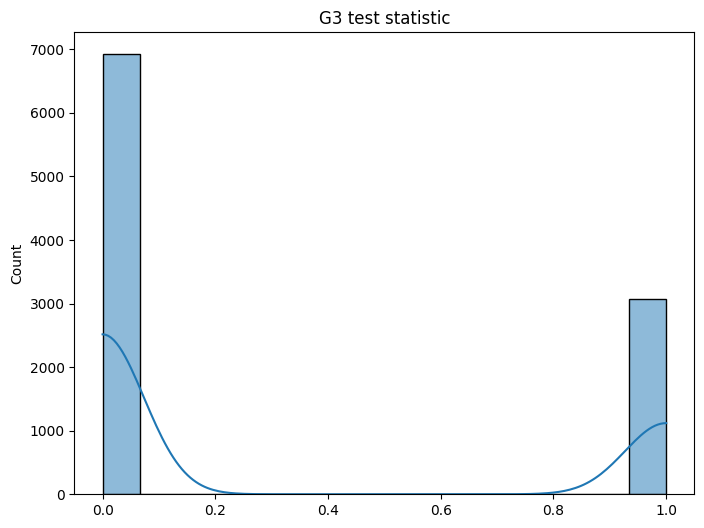

In [12]:
plt.figure(figsize=(8, 6))
sns.histplot(G3_list, kde=True) 

plt.title('G3 test statistic')
plt.show()

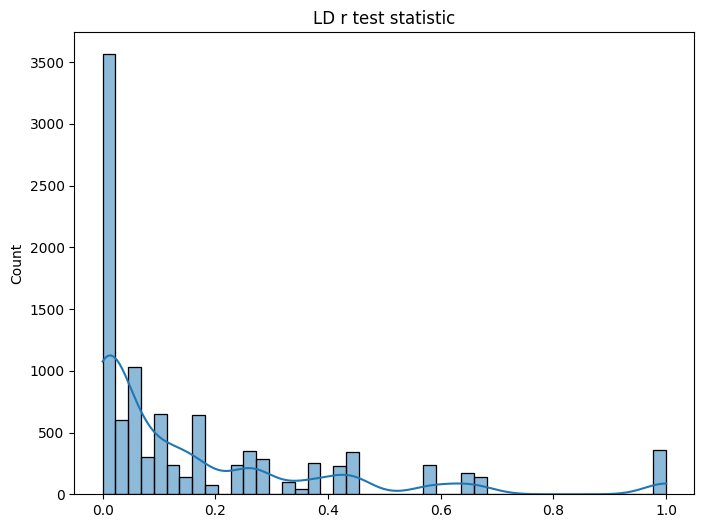

In [13]:
plt.figure(figsize=(8, 6))
sns.histplot(LD_r_list, kde=True) 

plt.title('LD r test statistic')
plt.show()

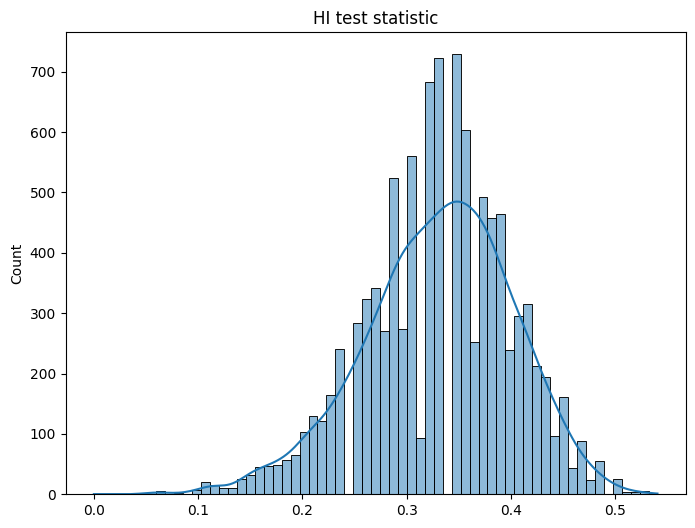

In [14]:
plt.figure(figsize=(8, 6))
sns.histplot(HI_list, kde=True) 

plt.title('HI test statistic')
plt.show()

### Truncated mutation

In [15]:
G3_list2 = []
LD_r_list2 = []
HI_list2 = []
np.random.seed(100)

for i in range(10000):
    ARG_i = ARG(tree1, 0.5, 100, 5.0, 20, "seq")

    node_site = add_mutation_truncated(ARG_i, 1.0)

    G3_list2.append(G3_test(node_site[:tree_width, :2]))
    LD_r_list2.append(LD_r(node_site[:tree_width, :2]))
    HI_list2.append(homoplasy_index(ARG_i, node_site))

    if i % 100 == 0:
        print(f'Completed {i} iterations.')

Completed 0 iterations.
Completed 100 iterations.
Completed 200 iterations.
Completed 300 iterations.
Completed 400 iterations.
Completed 500 iterations.
Completed 600 iterations.
Completed 700 iterations.
Completed 800 iterations.
Completed 900 iterations.
Completed 1000 iterations.
Completed 1100 iterations.
Completed 1200 iterations.
Completed 1300 iterations.
Completed 1400 iterations.
Completed 1500 iterations.
Completed 1600 iterations.
Completed 1700 iterations.
Completed 1800 iterations.
Completed 1900 iterations.
Completed 2000 iterations.
Completed 2100 iterations.
Completed 2200 iterations.
Completed 2300 iterations.
Completed 2400 iterations.
Completed 2500 iterations.
Completed 2600 iterations.
Completed 2700 iterations.
Completed 2800 iterations.
Completed 2900 iterations.
Completed 3000 iterations.
Completed 3100 iterations.
Completed 3200 iterations.
Completed 3300 iterations.
Completed 3400 iterations.
Completed 3500 iterations.
Completed 3600 iterations.
Completed 370

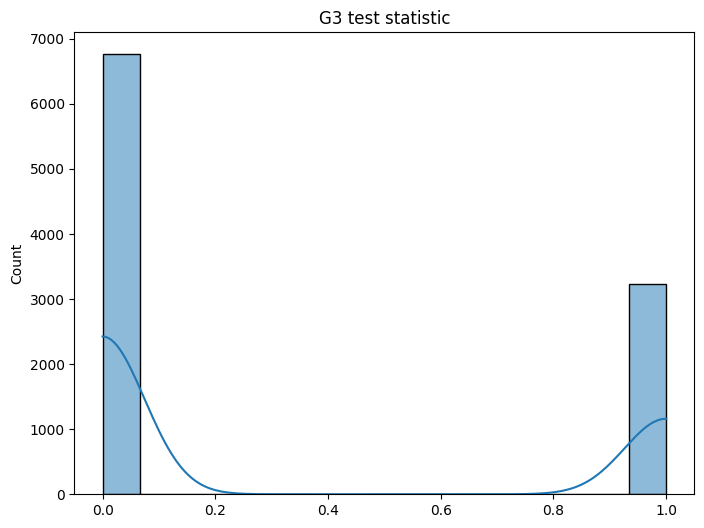

In [16]:
plt.figure(figsize=(8, 6))
sns.histplot(G3_list2, kde=True) 

plt.title('G3 test statistic')
plt.show()

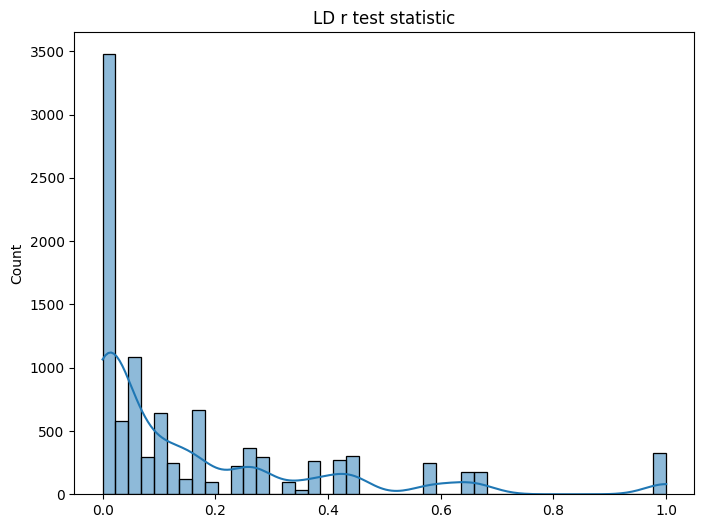

In [17]:
plt.figure(figsize=(8, 6))
sns.histplot(LD_r_list2, kde=True) 

plt.title('LD r test statistic')
plt.show()

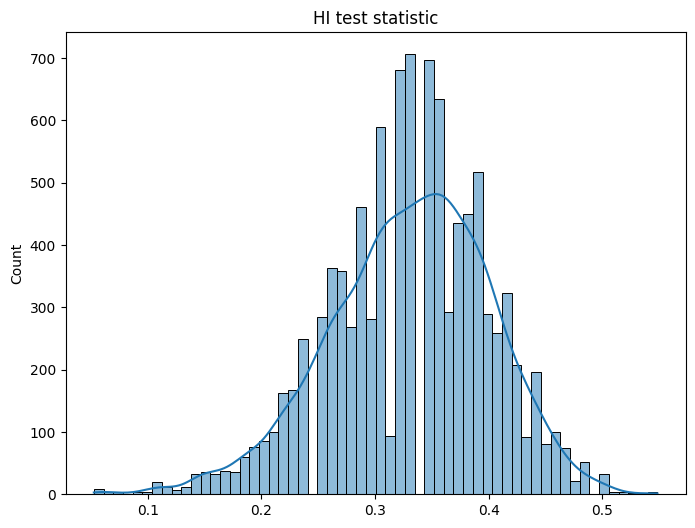

In [18]:
plt.figure(figsize=(8, 6))
sns.histplot(HI_list2, kde=True) 

plt.title('HI test statistic')
plt.show()

## Simulator and summary statistics

In [19]:
ARG_2 = ARG(tree1, 0.5, 100, 5.0, 100, "seq")
node_site = add_mutation_truncated(ARG_2, 1.0)

In [20]:
node_site.shape

(451, 100)

In [21]:
node_site.shape[1]

100

In [22]:
s_vec = ClonalOrigin_seq_simulator(tree1, 0.5, 1.0, 1000, 10, k_vec=[50, 200, 500])
s_vec

array([1.23245030e-01, 1.26158118e-01, 1.21630263e-01, 3.43157895e-01,
       3.55000000e-01, 3.66000000e-01, 3.54182366e-01, 4.46102882e-04,
       1.00000000e+03])